# Emotion Detection using RoBERTa-base

## Project
AI Mental Health Chatbot — Final Year Project

## Dataset
dair-ai/emotion

## Task
Multi-class emotion classification

## Number of Classes
6

## Classes
0 — Sadness
1 — Joy
2 — Love
3 — Anger
4 — Fear
5 — Surprise

## Base Model
RoBERTa-base

## Fine-tuned Model
emotion_dair_ai_roberta

In [1]:
import os
import json
import time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

print("Environment loaded successfully.")
print("PyTorch version:", torch.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

c:\Users\HP\Desktop\Mental-Health-Chatbot\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Environment loaded successfully.
PyTorch version: 2.13.0+cpu
Device: cpu


In [2]:
from pathlib import Path

BACKEND_DIR = Path.cwd().parent

RAW_DIR = BACKEND_DIR / "datasets" / "emotion_dataset" / "raw"
PROCESSED_DIR = BACKEND_DIR / "datasets" / "emotion_dataset" / "processed"
MODEL_DIR = BACKEND_DIR / "models" / "emotion_dair_ai_roberta"
EVALUATION_DIR = BACKEND_DIR / "evaluation"

print("Backend:", BACKEND_DIR)
print("Raw:", RAW_DIR)
print("Processed:", PROCESSED_DIR)
print("Model:", MODEL_DIR)
print("Evaluation:", EVALUATION_DIR)

Backend: c:\Users\HP\Desktop\Mental-Health-Chatbot\backend
Raw: c:\Users\HP\Desktop\Mental-Health-Chatbot\backend\datasets\emotion_dataset\raw
Processed: c:\Users\HP\Desktop\Mental-Health-Chatbot\backend\datasets\emotion_dataset\processed
Model: c:\Users\HP\Desktop\Mental-Health-Chatbot\backend\models\emotion_dair_ai_roberta
Evaluation: c:\Users\HP\Desktop\Mental-Health-Chatbot\backend\evaluation


In [3]:
train_raw = pd.read_csv(RAW_DIR / "train.csv")
val_raw = pd.read_csv(RAW_DIR / "validation.csv")
test_raw = pd.read_csv(RAW_DIR / "test.csv")

print("Raw Train:", train_raw.shape)
print("Raw Validation:", val_raw.shape)
print("Raw Test:", test_raw.shape)

Raw Train: (16000, 2)
Raw Validation: (2000, 2)
Raw Test: (2000, 2)


In [4]:
display(train_raw.head())

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [37]:
print("Columns:", train_raw.columns.tolist())

Columns: ['text', 'label']


In [38]:
print([name for name in globals() if not name.startswith("_")])

['In', 'Out', 'get_ipython', 'exit', 'quit', 'open', 'os', 'json', 'time', 'pd', 'np', 'plt', 'torch', 'accuracy_score', 'precision_recall_fscore_support', 'classification_report', 'confusion_matrix', 'AutoTokenizer', 'AutoModelForSequenceClassification', 'Path', 'BACKEND_DIR', 'RAW_DIR', 'PROCESSED_DIR', 'MODEL_DIR', 'EVALUATION_DIR', 'train_raw', 'val_raw', 'test_raw', 'builtins', 'ipykernel', 'debugpy', 'file', 'clean', 'train', 'val', 'test', 'label_counts', 'label_mapping', 'label_id', 'emotion', 'samples', 'i', 'text', 'tokenizer', 'model', 'device', 'test_df', 'texts', 'true_labels', 'predicted_labels', 'prediction_confidences', 'BATCH_SIZE', 'start_time', 'start', 'batch_texts', 'encoded', 'outputs', 'probabilities', 'predictions', 'confidences', 'evaluation_time', 'accuracy', 'precision', 'recall', 'f1', 'macro_precision', 'macro_recall', 'macro_f1', 'target_labels', 'target_names', 'report', 'results_df', 'wrong_predictions', 'trainer_state_path', 'f', 'trainer_state', 'histo

In [5]:
print(train_raw.dtypes)

text     object
label     int64
dtype: object


In [6]:
print("Train missing values:")
display(train_raw.isnull().sum())

print("Validation missing values:")
display(val_raw.isnull().sum())

print("Test missing values:")
display(test_raw.isnull().sum())

Train missing values:


text     0
label    0
dtype: int64

Validation missing values:


text     0
label    0
dtype: int64

Test missing values:


text     0
label    0
dtype: int64

In [7]:
print("Train duplicate rows:", train_raw.duplicated().sum())
print("Validation duplicate rows:", val_raw.duplicated().sum())
print("Test duplicate rows:", test_raw.duplicated().sum())

Train duplicate rows: 1
Validation duplicate rows: 0
Test duplicate rows: 0


In [8]:
print("Train duplicate rows:", train_raw.duplicated().sum())
print("Validation duplicate rows:", val_raw.duplicated().sum())
print("Test duplicate rows:", test_raw.duplicated().sum())

Train duplicate rows: 1
Validation duplicate rows: 0
Test duplicate rows: 0


In [11]:
def clean(df):
    df = df.drop_duplicates()
    df = df.dropna()

    df["text"] = (
        df["text"]
        .str.lower()
        .str.strip()
    )

    return df

In [12]:
train = clean(train_raw.copy())
val = clean(val_raw.copy())
test = clean(test_raw.copy())

In [13]:
print("Processed Train:", train.shape)
print("Processed Validation:", val.shape)
print("Processed Test:", test.shape)

print("Total processed:",
      len(train) + len(val) + len(test))

Processed Train: (15999, 2)
Processed Validation: (2000, 2)
Processed Test: (2000, 2)
Total processed: 19999


In [14]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

train.to_csv(
    PROCESSED_DIR / "train_processed.csv",
    index=False
)

val.to_csv(
    PROCESSED_DIR / "validation_processed.csv",
    index=False
)

test.to_csv(
    PROCESSED_DIR / "test_processed.csv",
    index=False
)

print("Processed datasets saved successfully.")

Processed datasets saved successfully.


In [15]:
print("Train label distribution:")
display(train["label"].value_counts().sort_index())

print("Validation label distribution:")
display(val["label"].value_counts().sort_index())

print("Test label distribution:")
display(test["label"].value_counts().sort_index())

Train label distribution:


label
0    4666
1    5361
2    1304
3    2159
4    1937
5     572
Name: count, dtype: int64

Validation label distribution:


label
0    550
1    704
2    178
3    275
4    212
5     81
Name: count, dtype: int64

Test label distribution:


label
0    581
1    695
2    159
3    275
4    224
5     66
Name: count, dtype: int64

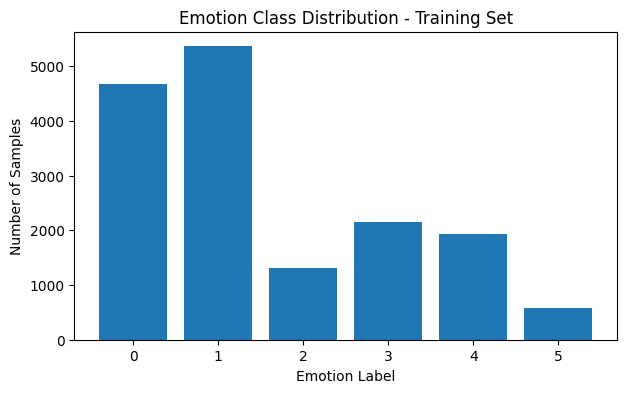

In [16]:
label_counts = train["label"].value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar(label_counts.index.astype(str), label_counts.values)
plt.title("Emotion Class Distribution - Training Set")
plt.xlabel("Emotion Label")
plt.ylabel("Number of Samples")
plt.show()

In [17]:
label_mapping = {
    0: "Sadness",
    1: "Joy",
    2: "Love",
    3: "Anger",
    4: "Fear",
    5: "Surprise"
}

label_mapping

{0: 'Sadness', 1: 'Joy', 2: 'Love', 3: 'Anger', 4: 'Fear', 5: 'Surprise'}

In [18]:
for label_id, emotion in label_mapping.items():
    print(f"\n===== {emotion} ({label_id}) =====")

    samples = train[
        train["label"] == label_id
    ]["text"].head(3)

    for i, text in enumerate(samples, 1):
        print(f"{i}. {text}")


===== Sadness (0) =====
1. i didnt feel humiliated
2. i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
3. ive been feeling a little burdened lately wasnt sure why that was

===== Joy (1) =====
1. i have been with petronas for years i feel that petronas has performed well and made a huge profit
2. i do feel that running is a divine experience and that i can expect to have some type of spiritual encounter
3. i have immense sympathy with the general point but as a possible proto writer trying to find time to write in the corners of life and with no sign of an agent let alone a publishing contract this feels a little precious

===== Love (2) =====
1. i am ever feeling nostalgic about the fireplace i will know that it is still on the property
2. i feel romantic too
3. i can t let go of that sad feeling that i want to be accepted here in this first home of mine

===== Anger (3) =====
1. im grabbing a minute to post i feel greedy wr

## Model Configuration

- Base model: RoBERTa-base
- Number of classes: 6
- Maximum sequence length: 128
- Epochs: 3
- Learning rate: 2e-5
- Training batch size: 4
- Evaluation batch size: 4
- Gradient accumulation steps: 2
- Weight decay: 0.01
- Optimizer: AdamW (`adamw_torch_fused`)
- Random seed: 42
- Best model criterion: validation accuracy

In [19]:
tokenizer = AutoTokenizer.from_pretrained(
    str(MODEL_DIR)
)

model = AutoModelForSequenceClassification.from_pretrained(
    str(MODEL_DIR)
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model.to(device)
model.eval()

print("Model loaded successfully.")
print("Device:", device)
print("Number of classes:", model.config.num_labels)

Model loaded successfully.
Device: cpu
Number of classes: 6


In [20]:
test_df = pd.read_csv(
    PROCESSED_DIR / "test_processed.csv"
)

texts = test_df["text"].astype(str).tolist()
true_labels = test_df["label"].astype(int).tolist()

predicted_labels = []
prediction_confidences = []

BATCH_SIZE = 16

start_time = time.time()

for start in range(0, len(texts), BATCH_SIZE):

    batch_texts = texts[start:start + BATCH_SIZE]

    encoded = tokenizer(
        batch_texts,
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors="pt"
    )

    encoded = {
        key: value.to(device)
        for key, value in encoded.items()
    }

    with torch.no_grad():

        outputs = model(**encoded)

        probabilities = torch.softmax(
            outputs.logits,
            dim=-1
        )

        predictions = torch.argmax(
            probabilities,
            dim=-1
        )

        confidences = torch.max(
            probabilities,
            dim=-1
        ).values

    predicted_labels.extend(
        predictions.cpu().numpy().tolist()
    )

    prediction_confidences.extend(
        confidences.cpu().numpy().tolist()
    )

evaluation_time = time.time() - start_time

print("Evaluation time:", round(evaluation_time, 2), "seconds")

Evaluation time: 387.9 seconds


In [24]:
accuracy = accuracy_score(
    true_labels,
    predicted_labels
)

precision, recall, f1, _ = (
    precision_recall_fscore_support(
        true_labels,
        predicted_labels,
        average="weighted",
        zero_division=0
    )
)

macro_precision, macro_recall, macro_f1, _ = (
    precision_recall_fscore_support(
        true_labels,
        predicted_labels,
        average="macro",
        zero_division=0
    )
)

print("Accuracy:", accuracy)
print("Weighted Precision:", precision)
print("Weighted Recall:", recall)
print("Weighted F1:", f1)
print("Macro Precision:", macro_precision)
print("Macro Recall:", macro_recall)
print("Macro F1:", macro_f1)

Accuracy: 0.9295
Weighted Precision: 0.9316985819232472
Weighted Recall: 0.9295
Weighted F1: 0.9283933752007917
Macro Precision: 0.9092195321131991
Macro Recall: 0.8739430753631936
Macro F1: 0.8868119870811711


In [25]:
target_labels = sorted(
    set(true_labels) | set(predicted_labels)
)

target_names = [
    label_mapping[label]
    for label in target_labels
]

report = classification_report(
    true_labels,
    predicted_labels,
    labels=target_labels,
    target_names=target_names,
    digits=4,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

     Sadness     0.9786    0.9466    0.9624       581
         Joy     0.9332    0.9655    0.9491       695
        Love     0.9360    0.7358    0.8239       159
       Anger     0.9307    0.9273    0.9290       275
        Fear     0.8277    0.9866    0.9002       224
    Surprise     0.8491    0.6818    0.7563        66

    accuracy                         0.9295      2000
   macro avg     0.9092    0.8739    0.8868      2000
weighted avg     0.9317    0.9295    0.9284      2000



In [26]:
target_labels = sorted(
    set(true_labels) | set(predicted_labels)
)

target_names = [
    label_mapping[label]
    for label in target_labels
]

report = classification_report(
    true_labels,
    predicted_labels,
    labels=target_labels,
    target_names=target_names,
    digits=4,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

     Sadness     0.9786    0.9466    0.9624       581
         Joy     0.9332    0.9655    0.9491       695
        Love     0.9360    0.7358    0.8239       159
       Anger     0.9307    0.9273    0.9290       275
        Fear     0.8277    0.9866    0.9002       224
    Surprise     0.8491    0.6818    0.7563        66

    accuracy                         0.9295      2000
   macro avg     0.9092    0.8739    0.8868      2000
weighted avg     0.9317    0.9295    0.9284      2000



In [40]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    true_labels,
    predicted_labels
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[550   4   0  18   9   0]
 [  4 671   8   1   3   8]
 [  0  42 117   0   0   0]
 [  3   2   0 255  15   0]
 [  3   0   0   0 221   0]
 [  2   0   0   0  19  45]]


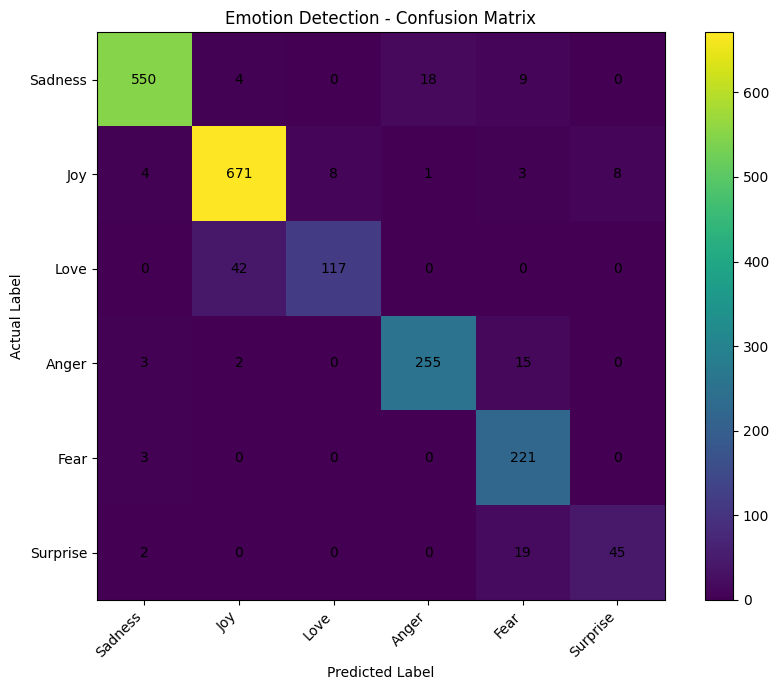

In [41]:
plt.figure(figsize=(9, 7))

plt.imshow(cm)

plt.title("Emotion Detection - Confusion Matrix")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    range(len(target_names)),
    target_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(target_names)),
    target_names
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

In [39]:
results_df = test_df.copy()

results_df["predicted_label"] = predicted_labels
results_df["prediction_confidence"] = prediction_confidences

results_df["actual_emotion"] = (
    results_df["label"].map(label_mapping)
)

results_df["predicted_emotion"] = (
    results_df["predicted_label"].map(label_mapping)
)

results_df["correct"] = (
    results_df["label"] ==
    results_df["predicted_label"]
)

display(results_df.head(10))

,text,label,predicted_label,prediction_confidence,actual_emotion,predicted_emotion,correct
0,im feeling rather rotten so im not very ambiti...,0,0,0.999440,Sadness,Sadness,True
1,im updating my blog because i feel shitty,0,0,0.999516,Sadness,Sadness,True
2,i never make her separate from me because i do...,0,0,0.999474,Sadness,Sadness,True
3,i left with my bouquet of red and yellow tulip...,1,1,0.999542,Joy,Joy,True
4,i was feeling a little vain when i did this one,0,0,0.999452,Sadness,Sadness,True
5,i cant walk into a shop anywhere where i do no...,4,4,0.998748,Fear,Fear,True
6,i felt anger when at the end of a telephone call,3,3,0.998840,Anger,Anger,True
7,i explain why i clung to a relationship with a...,1,1,0.998723,Joy,Joy,True
8,i like to have the same breathless feeling as ...,1,1,0.999597,Joy,Joy,True
9,i jest i feel grumpy tired and pre menstrual w...,3,3,0.998861,Anger,Anger,True


In [29]:
wrong_predictions = results_df[
    results_df["correct"] == False
]

print("Wrong predictions:", len(wrong_predictions))

display(
    wrong_predictions.head(10)
)

Wrong predictions: 141


,text,label,predicted_label,prediction_confidence,actual_emotion,predicted_emotion,correct
72,i am right handed however i play billiards lef...,5,4,0.619339,Surprise,Fear,False
74,i were to go overseas or cross the border then...,2,1,0.566389,Love,Joy,False
94,when a friend dropped a frog down my neck,3,4,0.976204,Anger,Fear,False
96,i love neglecting this blog but sometimes i fe...,2,1,0.591725,Love,Joy,False
98,i feel my heart is tortured by what i have done,3,4,0.978921,Anger,Fear,False
111,i feel is he generous,2,1,0.915189,Love,Joy,False
119,i feel like i know who most of them are by now...,1,0,0.941002,Joy,Sadness,False
121,made a wonderfull new friend,1,5,0.932444,Joy,Surprise,False
131,im feeling generous today heres one more you m...,2,1,0.923283,Love,Joy,False
137,i actually feel agitated which led to a terrib...,3,4,0.988602,Anger,Fear,False


In [30]:
print("=" * 60)
print("FINAL EMOTION TEST RESULTS")
print("=" * 60)

print(f"Test Samples        : {len(test_df)}")
print(f"Accuracy            : {accuracy * 100:.2f}%")
print(f"Weighted Precision   : {precision * 100:.2f}%")
print(f"Weighted Recall      : {recall * 100:.2f}%")
print(f"Weighted F1          : {f1 * 100:.2f}%")
print(f"Macro Precision      : {macro_precision * 100:.2f}%")
print(f"Macro Recall         : {macro_recall * 100:.2f}%")
print(f"Macro F1             : {macro_f1 * 100:.2f}%")
print(f"Correct Predictions  : {int(results_df['correct'].sum())}")
print(f"Wrong Predictions    : {int((~results_df['correct']).sum())}")
print(f"Evaluation Time      : {evaluation_time:.2f} seconds")

FINAL EMOTION TEST RESULTS
Test Samples        : 2000
Accuracy            : 92.95%
Weighted Precision   : 93.17%
Weighted Recall      : 92.95%
Weighted F1          : 92.84%
Macro Precision      : 90.92%
Macro Recall         : 87.39%
Macro F1             : 88.68%
Correct Predictions  : 1859
Wrong Predictions    : 141
Evaluation Time      : 387.90 seconds


In [31]:
trainer_state_path = (
    MODEL_DIR /
    "checkpoint-6000" /
    "trainer_state.json"
)

with open(trainer_state_path, "r", encoding="utf-8") as f:
    trainer_state = json.load(f)

history = pd.DataFrame(
    trainer_state["log_history"]
)

history.head()

,epoch,grad_norm,learning_rate,loss,step,eval_accuracy,eval_f1,eval_loss,eval_precision,eval_recall,eval_runtime,eval_samples_per_second,eval_steps_per_second
0,0.05,18.000042,0.000020,1.5905,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.10,8.741930,0.000019,1.2623,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.15,17.601820,0.000019,0.9365,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.20,18.750977,0.000019,0.7419,400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.25,122.748650,0.000018,0.6549,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


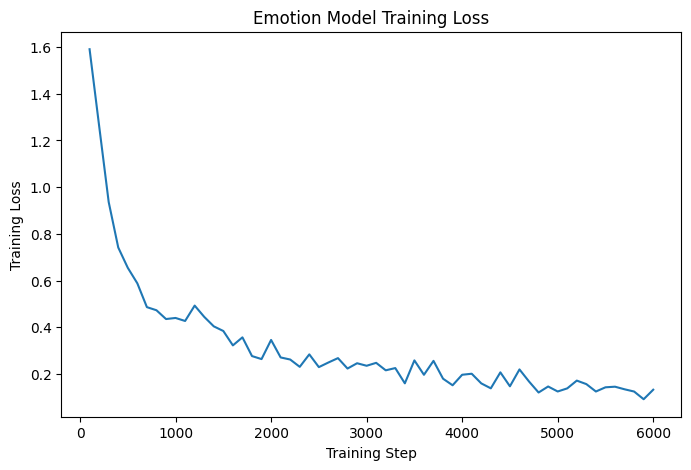

In [32]:
train_history = history[
    history["loss"].notna()
]

plt.figure(figsize=(8, 5))
plt.plot(
    train_history["step"],
    train_history["loss"]
)
plt.xlabel("Training Step")
plt.ylabel("Training Loss")
plt.title("Emotion Model Training Loss")
plt.show()

## Conclusion

The RoBERTa-base model was fine-tuned for six-class emotion classification using the dair-ai/emotion dataset. The raw data was cleaned by removing duplicate and missing records and by converting text to lowercase and removing leading/trailing whitespace. The processed dataset contained separate training, validation, and testing subsets.

The trained model was evaluated on the independent test split. The final evaluation included accuracy, weighted and macro precision, recall, F1-score, classification report, and confusion matrix. Individual predictions and incorrect predictions were also inspected for error analysis.

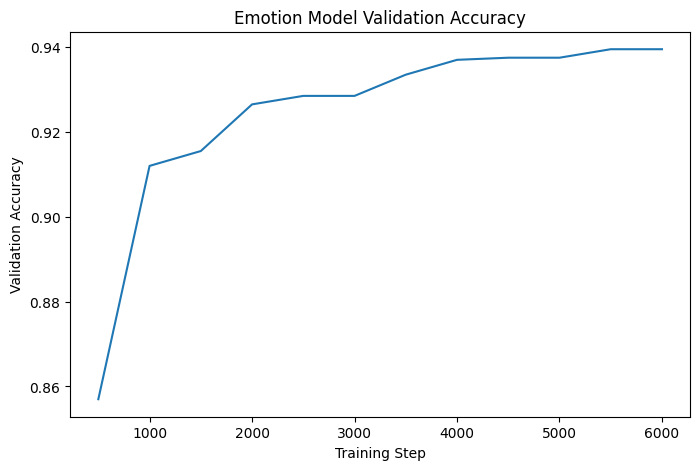

In [33]:
eval_history = history[
    history["eval_accuracy"].notna()
]

plt.figure(figsize=(8, 5))
plt.plot(
    eval_history["step"],
    eval_history["eval_accuracy"]
)
plt.xlabel("Training Step")
plt.ylabel("Validation Accuracy")
plt.title("Emotion Model Validation Accuracy")
plt.show()